# Create known-maximum-sized image datasets from folders of images.

In [2]:
import hierarchical_binary_quantization.misc.dataset_helpers as dh
import hierarchical_binary_quantization.misc.image_helpers as ih
from torchvision import transforms
import os


In [3]:
def recreate_database(name,src_path,w=240,h=320):
    output_db = f"data/dbs/{name}_{w}x{h}.sqlite3"
    if os.path.exists(output_db):
        print(f"{output_db} already exists")
        return
    print(output_db)
    dh.make_w_h_dataset(src_path,output_db,w=w,h=h)

In [4]:
recreate_database("fantasy","data/fantasy",w=384,h=384)

data/dbs/fantasy_384x384.sqlite3 already exists


In [5]:
sources = [
        ("fantasy","data/fantasy"),
        ("pokemon","data/pokemon_archive"),
        ("cats_and_dogs","data/cats_and_dogs"),
        ("yugioh","data/yugioh"),
        ("mnist_scaled","data/256x256/mnist_scaled"),
        ("mnist_grid","data/256x256/mnist_grid"),
    ]
sizes = [(64,64), (128,128), (256,256)]
for w,h in sizes:
    for n,p in sources:
        recreate_database(n,p,w=w,h=h)


portrait_sources = [
        ("fantasy","data/fantasy"),
]
sizes = [(224,320),(384,512)]
for w,h in sizes:
    for n,p in portrait_sources:
        recreate_database(n,p,w=w,h=h)



data/dbs/fantasy_64x64.sqlite3 already exists
data/dbs/pokemon_64x64.sqlite3 already exists
data/dbs/cats_and_dogs_64x64.sqlite3 already exists
data/dbs/yugioh_64x64.sqlite3 already exists
data/dbs/mnist_scaled_64x64.sqlite3 already exists
data/dbs/mnist_grid_64x64.sqlite3 already exists
data/dbs/fantasy_128x128.sqlite3 already exists
data/dbs/pokemon_128x128.sqlite3 already exists
data/dbs/cats_and_dogs_128x128.sqlite3 already exists
data/dbs/yugioh_128x128.sqlite3 already exists
data/dbs/mnist_scaled_128x128.sqlite3 already exists
data/dbs/mnist_grid_128x128.sqlite3 already exists
data/dbs/fantasy_256x256.sqlite3 already exists
data/dbs/pokemon_256x256.sqlite3 already exists
data/dbs/cats_and_dogs_256x256.sqlite3 already exists
data/dbs/yugioh_256x256.sqlite3 already exists
data/dbs/mnist_scaled_256x256.sqlite3 already exists
data/dbs/mnist_grid_256x256.sqlite3 already exists
data/dbs/fantasy_224x320.sqlite3 already exists
data/dbs/fantasy_384x512.sqlite3 already exists


## Verify that the dataset was created reasonably

torch.Size([3, 320, 240])


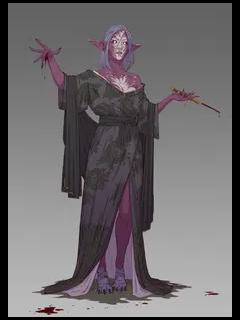

In [ ]:
W,H = 240,320
transform = transforms.Compose([
    dh.PadToRectangle(width=W, height=H),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
bds = dh.BlobDataset("data/dbs/fantasy_224x320.sqlite3","r")
imgds = dh.ImageDataset(bds, transform)
next(iter(imgds))
print(imgds[10][1].shape) # [C, H, W]
ih.tensor_to_pil(imgds[10][1])